In [1]:
library(Seurat)
library(scattermore)
library(tidyverse)
library(data.table)
library(wesanderson)
library(patchwork)
library(RColorBrewer)
library(furrr)
library(paletteer)
library(arrow)
library(pheatmap)
library(distances)
library(cowplot)
library(ComplexHeatmap)
library(circlize)
library(grid)
library(ggplot2)
library(scattermore)
library(dplyr)
options(future.globals.maxSize = 1000 * 1024^2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked 

In [2]:
ColorPalette<-function()
{ 
  Colors <- c(
    "#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00",
    "#A65628", "#F781BF", "#999999", "#66C2A5", "#FC8D62",
    "#8DA0CB", "#E78AC3", "#A6D854", "#FFD92F", "#E5C494",
    "#B3B3B3", "#1B9E77", "#D95F02", "#7570B3", "#E7298A",
    "#66A61E", "#E6AB02", "#A6761D", "#666666", "#8DD3C7",
    "#FFFFB3", "#BEBADA", "#FB8072", "#80B1D3", "#FDB462",
    "#B3DE69", "#FCCDE5", "#D9D9D9", "#BC80BD", "#CCEBC5",
    "#FFED6F", "#F4A582", "#92C5DE", "#B2182B", "#4D9221",
    "black"
  )
  names(Colors)<-c('Tumor III','Plasma','Macrophage','CD4 T cell','CAF','vSM','Mature B','Endothelial','Tumor I','CD8 T cell',
                   'Enterocyte','Neutrophil','Proliferating Immune II','Pericytes','Smooth Muscle','Myofibroblast',
                   'Tumor II','Fibroblast','Goblet','Lymphatic Endothelial','Tumor V','Proliferating Macrophages','SM Stress Response',
                   'NK','cDC I','Tumor IV','Proliferating Fibroblast','Epithelial','Tuft','Mast','Unknown III (SM)',
                   'Adipocyte','mRegDC','Enteric Glial','pDC','Vascular Fibroblast','Neuroendocrine','Memory B','Unknwon I (Immune)',"Undetermined","cell")
  
  return(Colors)
  
}

In [3]:
# load ST data
all_obj <- readRDS("../Data/GSE280318_processed.rds")


Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


The following object is masked from ‘package:lubridate’:

    stamp




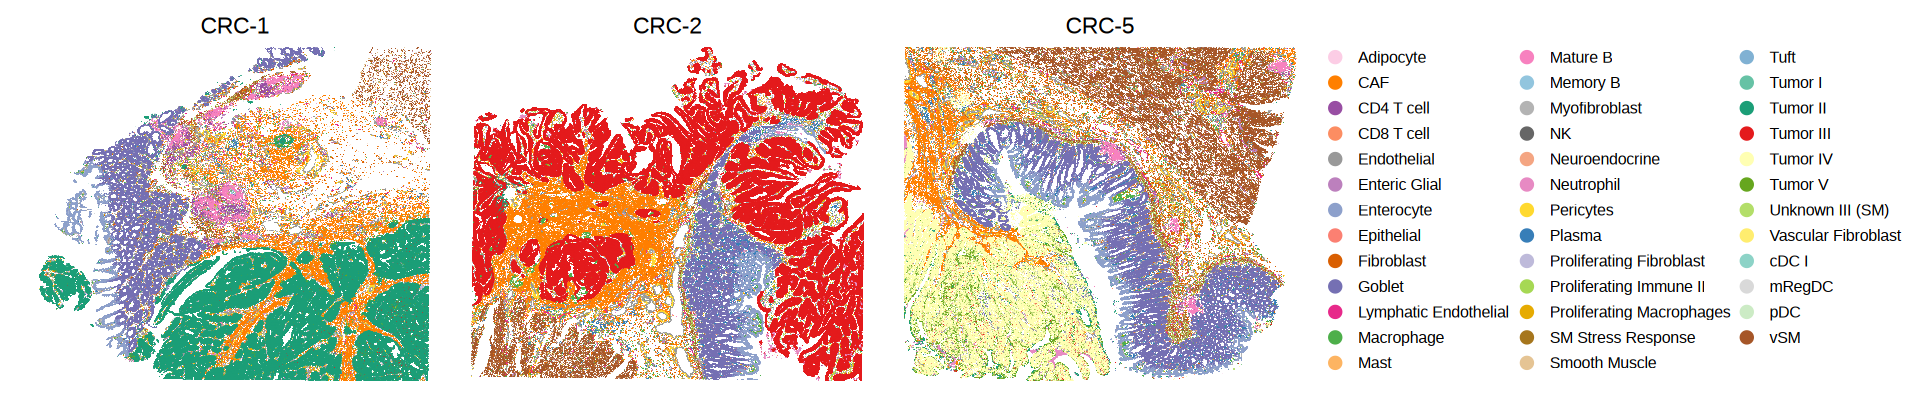

In [4]:
# Fig 2A
options(repr.plot.width = 16, repr.plot.height = 3.5) 

# The deconvolution results from "High definition spatial transcriptomic profiling of immune cell populations in colorectal cancer"
p1 <- all_obj[[]] %>% filter(slice=='CRC1' & tissue==1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color=DeconvolutionLabel1)) +
  geom_scattermore(pointsize = 3, pixels = rep(2000,2))+
  coord_cartesian(expand = FALSE) +
  xlab("") + ylab("") +
  theme_set(theme_bw(base_size = 10))+
  theme_minimal() +
  theme(axis.text = element_blank(),
        panel.grid.minor = element_blank(),
        panel.grid.major = element_blank(),
        plot.title = element_text(hjust = 0.5))+
  scale_color_manual(values=ColorPalette())+
  ggtitle("CRC-1") + NoLegend()

p2 <- all_obj[[]] %>% filter(slice=='CRC2' & tissue==1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color=DeconvolutionLabel1)) +
  geom_scattermore(pointsize = 3, pixels = rep(2000,2))+
  coord_cartesian(expand = FALSE) +
  xlab("") + ylab("") +
  theme_set(theme_bw(base_size = 10))+
  theme_minimal() +
  theme(axis.text = element_blank(),
        panel.grid.minor = element_blank(),
        panel.grid.major = element_blank(),
        plot.title = element_text(hjust = 0.5))+
  scale_color_manual(values=ColorPalette())+
  ggtitle("CRC-2") + NoLegend()

p3 <- all_obj[[]] %>% filter(slice=='CRC5' & tissue==1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color=DeconvolutionLabel1)) +
  geom_scattermore(pointsize = 3, pixels = rep(2000,2))+
  coord_cartesian(expand = FALSE) +
  xlab("") + ylab("") +
  theme_set(theme_bw(base_size = 10))+
  theme_minimal() +
  theme(axis.text = element_blank(),
        panel.grid.minor = element_blank(),
        panel.grid.major = element_blank(),
        plot.title = element_text(hjust = 0.5))+
  scale_color_manual(values=ColorPalette())+
  ggtitle("CRC-5") + NoLegend()

# extract legend
p_legend <- all_obj[[]] %>% filter(slice=='CRC1' & tissue==1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color=DeconvolutionLabel1)) +
  geom_scattermore(pointsize = 2, pixels = rep(2000,2))+
  scale_color_manual(values=ColorPalette())+
  guides(color = guide_legend(ncol = 3, title = NULL,override.aes = list(size = 3))) +
  theme(legend.position = "right",legend.text = element_text(size = 9),legend.key.spacing.y = unit(-2, "pt"),plot.margin = margin(0, 0, 0, 0))

legend <- get_legend(p_legend)

# print
(p1 | p2 | p3 | legend) + 
  plot_layout(widths = c(1, 1,1,1.5))


[1] TRUE

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))
! pheatmap() has been masked by ComplexHeatmap::pheatmap(). Most of the arguments
   in the original pheatmap() are identically supported in the new function. You 
   can still use the original function by explicitly calling pheatmap::pheatmap().



Attaching package: ‘Co

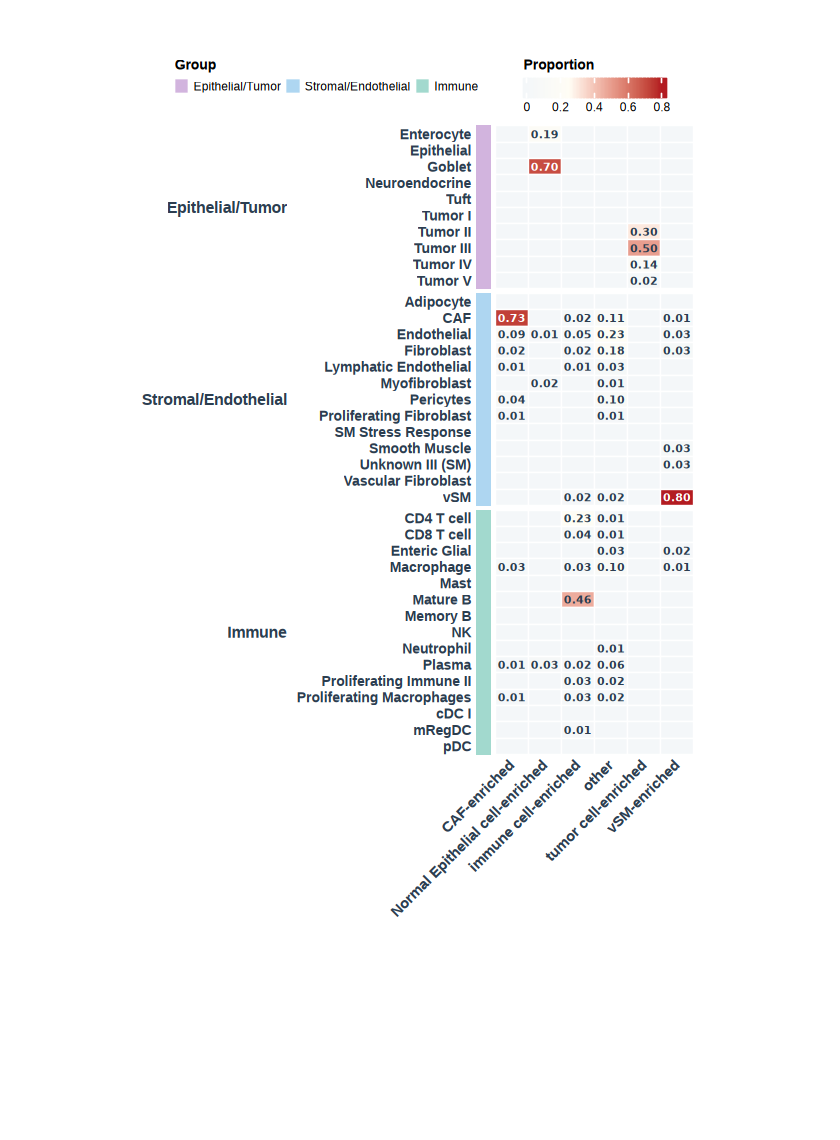

In [5]:
# Fig 2B
library(pheatmap)
library(dplyr)
options(repr.plot.width = 7, repr.plot.height = 9.5) 

niches <- readRDS('../Data/GSE280318_sptail_regions.rds')
identical(rownames(niches),rownames(all_obj[[]]))
all_obj$niches <- niches$niches2

all_obj$region <- case_match(
  all_obj$niches,
  "CRC1_1"   ~ "Normal Epithelial cell-enriched",
  "CRC1_2"   ~ "CAF-enriched",
  "CRC1_3"   ~ "vSM-enriched",
  "CRC1_4"   ~ "tumor cell-enriched",
  "CRC1_5"   ~ "immune cell-enriched",
  "CRC1_6"   ~ "other",
  "CRC2_1"   ~ "Normal Epithelial cell-enriched",
  "CRC2_2"   ~ "tumor cell-enriched",
  "CRC2_3"   ~ "vSM-enriched",
  "CRC2_4"   ~ "other",
  "CRC2_5"   ~ "CAF-enriched",
  "CRC5_1"   ~ "CAF-enriched",
  "CRC5_2"   ~ "Normal Epithelial cell-enriched",
  "CRC5_3"   ~ "immune cell-enriched",
  "CRC5_4"   ~ "other",
  "CRC5_5"   ~ "tumor cell-enriched",
  "CRC5_6"   ~ "vSM-enriched",
)

# raw count
count_matrix <- table(all_obj$region, all_obj$DeconvolutionLabel1)
prop_matrix <- count_matrix/rowSums(count_matrix)


# =======================
# prepare data
# =======================
mat_data <- prop_matrix  
mat_t <- t(mat_data)     

orig_cell_order <- rownames(mat_t)
orig_niche_order <- colnames(mat_t)

lineage <- case_when(
  orig_cell_order %in% c("Tumor I", "Tumor II", "Tumor III", "Tumor IV", "Tumor V", 
                    "Epithelial", "Enterocyte", "Goblet", "Tuft", "Neuroendocrine") ~ "Epithelial/Tumor",
  orig_cell_order %in% c("CAF", "Fibroblast", "Myofibroblast", "Proliferating Fibroblast", 
                    "Vascular Fibroblast", "vSM", "Smooth Muscle", "Pericytes", 
                    "Endothelial", "Lymphatic Endothelial", "Adipocyte", "SM Stress Response", 
                    "Unknown III (SM)") ~ "Stromal/Endothelial",
  TRUE ~ "Immune"
)

lineage_factor <- factor(lineage, levels = c("Epithelial/Tumor", "Stromal/Endothelial", "Immune"))


# =============
# create legend
# =============
col_fun = colorRamp2(
  c(0, 0.25, 0.8), 
  c("#F4F7F9", "#FFFDF5", "#B31B21") 
)

lineage_colors <- c(
  "Epithelial/Tumor" = "#D2B4DE",     
  "Stromal/Endothelial" = "#AED6F1",  
  "Immune" = "#A2D9CE"          
)

# 1: Group
lgd_group = Legend(
  labels = names(lineage_colors),
  legend_gp = gpar(fill = lineage_colors),
  title = "Group",
  direction = "horizontal", 
  nrow = 1,
  title_gp = gpar(fontsize = 8, fontface = "bold"),
  labels_gp = gpar(fontsize = 7),
  grid_width = unit(0.3, "cm"),
  grid_height = unit(0.3, "cm")
)

# 2: Proportion
lgd_prop = Legend(
  col_fun = col_fun, 
  title = "Proportion", 
  direction = "horizontal", 
  legend_width = unit(3, "cm"),
  title_gp = gpar(fontsize = 8, fontface = "bold"),
  labels_gp = gpar(fontsize = 7)
)

# combined
pd = packLegend(
  lgd_group, lgd_prop, 
  direction = "horizontal", 
  column_gap = unit(1, "cm")
)

# ==========
#  Heatmap
# ==========
row_ann <- rowAnnotation(
  Group = lineage_factor,
  col = list(Group = lineage_colors),
  show_annotation_name = FALSE,
  simple_anno_size = unit(0.3, "cm"),
  show_legend = FALSE 
)

p_transposed_no_clust <- Heatmap(
  mat_t,
  col = col_fun,
  show_heatmap_legend = FALSE, 
  
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  
  row_split = lineage_factor,
  row_title_gp = gpar(fontsize = 9, fontface = "bold", col = "#2C3E50"),
  row_title_rot = 0,
  
  width = unit(ncol(mat_t) * 0.7, "cm"),   
  height = unit(nrow(mat_t) * 0.35, "cm"), 
  rect_gp = gpar(col = "white", lwd = 0.8), 
  
  left_annotation = row_ann,
  
  cell_fun = function(j, i, x, y, width, height, fill) {
    val <- mat_t[i, j]
    if(val >= 0.01) {
      rgb_vals <- col2rgb(col_fun(val))
      brightness <- (rgb_vals[1]*299 + rgb_vals[2]*587 + rgb_vals[3]*114) / 1000
      text_color <- ifelse(brightness < 135, "#FFFFFF", "#2C3E50")
      grid.text(
        sprintf("%.2f", val), x, y, 
        gp = gpar(col = text_color, fontsize = 6.5, fontface = "bold", fontfamily = "sans")
      )
    }
  },
  
  row_names_side = "left", 
  row_names_gp = gpar(fontsize = 8, fontface = "bold", col = "#2C3E50"),
  column_names_side = "bottom",
  column_names_gp = gpar(fontsize = 8.5, fontface = "bold", col = "#2C3E50"),
  column_names_rot = 45
)




draw(
  p_transposed_no_clust,
  padding = unit(c(2.8, 1, 1, 1), "cm") 
)

draw(
  pd, 
  x = unit(0.5, "npc"),                     
  y = unit(1, "npc") - unit(1.8, "cm"),     
  just = "centre"
)


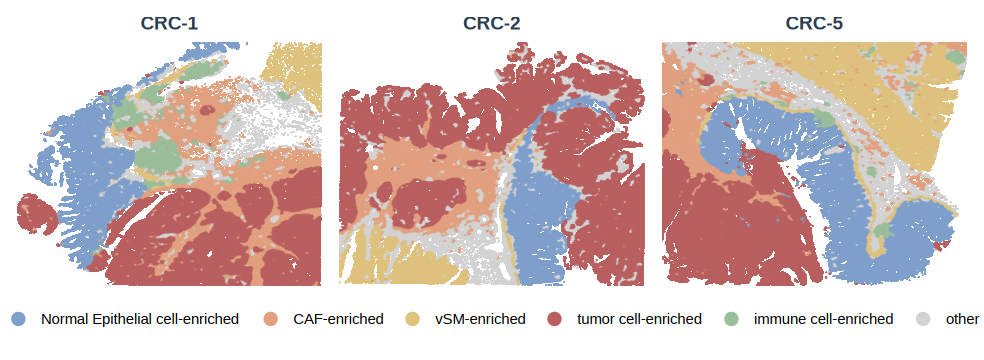

In [6]:
# Fig 2C
options(repr.plot.width = 8.2, repr.plot.height = 3) 


ColorPalette2 <- function() { 
  Colors <- c(
    "Normal Epithelial cell-enriched" = "#7F9FCB",
    "CAF-enriched"                    = "#E2A07F",
    "vSM-enriched"                    = "#DFC27D",
    "tumor cell-enriched"             = "#B95F5F",
    "immune cell-enriched"            = "#9ABD9A",
    "other"                           = "#D3D3D3"
  )
  return(Colors)
}

# sorting
all_obj$region <- factor(all_obj$region, levels = names(ColorPalette2()))

theme_spatial_publication <- function() {
  theme_minimal(base_size = 10) +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none", 
    plot.title = element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50"),
    plot.margin = margin(t = 5, r = 5, b = -8, l = 5, unit = "pt")
  )
}


p1 <- all_obj[[]] %>% 
  filter(slice == 'CRC1' & tissue == 1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color = region)) +
  geom_scattermore(pointsize = 8, pixels = rep(2000, 2)) +
  coord_cartesian(expand = FALSE) +
  scale_color_manual(values = ColorPalette2(), drop = FALSE) +
  ggtitle("CRC-1") +
  theme_spatial_publication()

p2 <- all_obj[[]] %>% 
  filter(slice == 'CRC2' & tissue == 1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color = region)) +
  geom_scattermore(pointsize = 8, pixels = rep(2000, 2)) +
  coord_cartesian(expand = FALSE) +
  scale_color_manual(values = ColorPalette2(), drop = FALSE) +
  ggtitle("CRC-2") +
  theme_spatial_publication()

p3 <- all_obj[[]] %>% 
  filter(slice == 'CRC5' & tissue == 1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color = region)) +
  geom_scattermore(pointsize = 8, pixels = rep(2000, 2)) +
  coord_cartesian(expand = FALSE) +
  scale_color_manual(values = ColorPalette2(), drop = FALSE) +
  ggtitle("CRC-5") +
  theme_spatial_publication()


p_legend <- all_obj[[]] %>% filter(slice=='CRC1' & tissue==1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color=region)) +
  geom_scattermore(pointsize = 2, pixels = rep(2000,2))+
  scale_color_manual(values=ColorPalette2())+
  guides(color = guide_legend(nrow = 1, title = NULL,override.aes = list(size = 3))) +  
  theme(legend.position = "bottom",legend.text = element_text(size = 8.5),legend.key.spacing.y = unit(-2, "pt"),plot.margin = margin(0, 0, 0, 0))

legend <- get_legend(p_legend)


((p1 | p2 | p3) / legend) + 
  plot_layout(heights = c(1,0.2))


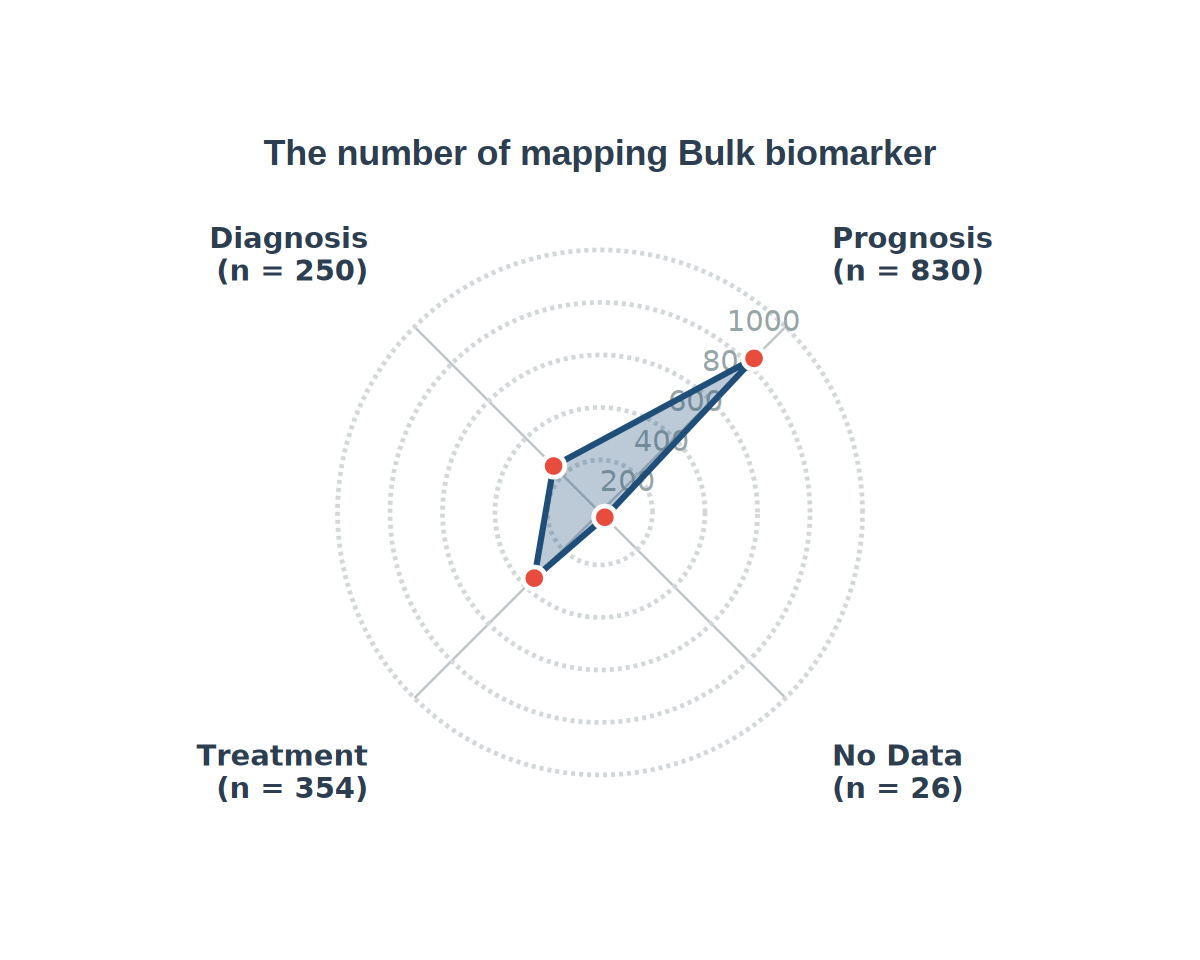

In [7]:
# Fig 2D
options(repr.plot.width = 10, repr.plot.height = 8) 

# Input data: count of bulk biomarkers by category
raw_vector <- c(
  "Prognosis"  = 830,
  "Diagnosis"  = 250,
  "Treatment"  = 354,
  "No Data"    = 26
)
# Format labels with sample counts
total_n <- sum(raw_vector)
pcts <- round(raw_vector / total_n * 100, 1)
formatted_names <- paste0(names(raw_vector), "\n(n = ", raw_vector, ")")
names(raw_vector) <- formatted_names


n_vars <- length(raw_vector)
max_val <- max(raw_vector)

# Set up radial grid breaks for concentric circles
grid_breaks <- pretty(c(0, max_val))
grid_breaks <- grid_breaks[grid_breaks > 0] 
grid_max <- max(grid_breaks)

# Calculate angular positions for each category
angles <- seq(0, 2 * pi, length.out = n_vars + 1)[1:n_vars] + pi / 4

# Generate coordinates for concentric grid circles
circle_points <- seq(0, 2 * pi, length.out = 200) 
grid_circles <- do.call(rbind, lapply(grid_breaks, function(r) {
  data.frame(
    x = r * cos(circle_points),
    y = r * sin(circle_points),
    r = r
  )
}))

# Generate coordinates for radial axes from center to edge
axis_data <- data.frame(
  x = 0, y = 0,
  xend = grid_max * cos(angles),
  yend = grid_max * sin(angles)
)

# Calculate coordinates for data points on the radar plot
data_points <- data.frame(
  name = names(raw_vector),
  val = as.numeric(raw_vector),
  x = as.numeric(raw_vector) * cos(angles),
  y = as.numeric(raw_vector) * sin(angles)
)

data_poly <- rbind(data_points, data_points[1, ])

# Prepare category label positions with automatic alignment
label_offset <- 1.25
label_data <- data.frame(
  name = names(raw_vector),
  x = grid_max * cos(angles) * label_offset,
  y = grid_max * sin(angles) * label_offset
) %>%
  mutate(
    
    hjust = ifelse(cos(angles) > 0.1, 0, ifelse(cos(angles) < -0.1, 1, 0.5)),
    vjust = ifelse(sin(angles) > 0.1, 0, ifelse(sin(angles) < -0.1, 1, 0.5))
  )

# Prepare radial grid value labels
grid_labels <- data.frame(
  r = grid_breaks,
  x = (grid_breaks - grid_max * 0.04) * cos(angles[1] + 0.08), 
  y = (grid_breaks - grid_max * 0.04) * sin(angles[1] + 0.08),
  label = as.character(grid_breaks)
)

# Build the radar chart with ggplot2
p_circular_radar <- ggplot() +
  
  
  geom_segment(
    data = axis_data, aes(x = x, y = y, xend = xend, yend = yend),
    color = "#BDC3C7", linewidth = 0.5
  ) +
  

  geom_path(
    data = grid_circles, aes(x = x, y = y, group = r),
    color = "#D2D7D9", linewidth = 1, linetype = "dashed"
  ) +
  

  geom_text(
    data = grid_labels, aes(x = x, y = y, label = label),
    color = "#95A5A6", size = 6, family = "sans", fontface = "italic"
  ) +
  

  geom_polygon(
    data = data_poly, aes(x = x, y = y),
    fill = "#1F4E79", alpha = 0.3
  ) +
  

  geom_path(
    data = data_poly, aes(x = x, y = y),
    color = "#1F4E79", linewidth = 1.3
  ) +
  

  geom_point(
    data = data_points, aes(x = x, y = y),
    shape = 21,
    fill = "#E74C3C",   
    color = "#FFFFFF",  
    stroke = 1.5,       
    size = 5          
  ) +
  

  geom_text(
    data = label_data, aes(x = x, y = y, label = name, hjust = hjust, vjust = vjust),
    color = "#2C3E50", size = 6, fontface = "bold", family = "sans", lineheight = 0.95
  ) +
  
  
  coord_equal(xlim = c(-grid_max * 1.55, grid_max * 1.55), ylim = c(-grid_max * 1.55, grid_max * 1.55)) +
  
  
  theme_void() +
  
  
  labs(title = "The number of mapping Bulk biomarker") +
  theme(
    plot.title = element_text(
      hjust = 0.5, vjust = -20, face = "bold", size = 21, 
      color = "#2C3E50", margin = margin(b = 20)
    )
  )
p_circular_radar


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.2 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.9 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.1 GiB”


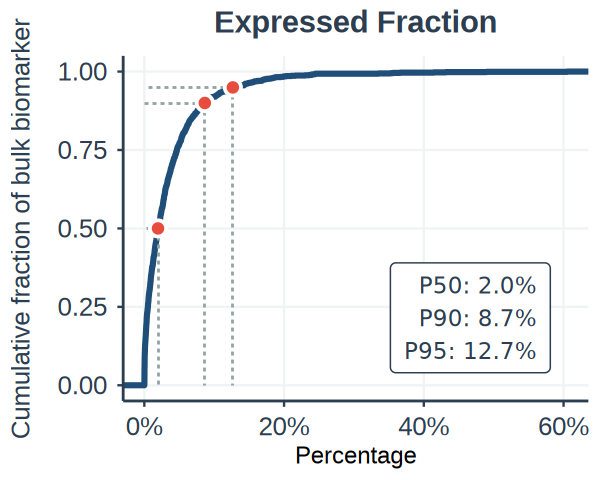

In [8]:
# Fig.2E
options(repr.plot.width = 5, repr.plot.height = 4) 

# Load bulk biomarkers and calculate expression fraction across cells
marker <- readRDS("../Data/GSE280318_bulk_biomarkers.rds")
marker_exp <- FetchData(all_obj,marker)
marker_exp_ind <- apply(marker_exp,2,function(x){sum(x>0)})
df <- data.frame(value = marker_exp_ind / nrow(marker_exp))  # 0~1 fraction

# Calculate quantiles (median, 90th, 95th) of non-zero expression fractions
nonzero <- df$value[df$value > 0]
q <- as.numeric(quantile(nonzero, probs = c(0.5, 0.9, 0.95), na.rm = TRUE))  # x at median/p90/p95

# Get corresponding cumulative probabilities from ECDF
F <- ecdf(df$value)
y_q <- as.numeric(F(q))  


xmin <- 0
xmax <- max(df$value, 0.001)
ymin <- 0
ymax <- 1


seg <- data.frame(
  x = q, y = y_q, xend = xmin, yend = y_q, type = "h_left"
)
seg2 <- data.frame(
  x = q, y = y_q, xend = q, yend = ymin, type = "v_down"
)
seg_all <- rbind(seg, seg2)


p <- ggplot(df, aes(x = value)) +
  
  stat_ecdf(geom = "step", linewidth = 1.3, color = "#1F4E79") +

  geom_segment(
    data = seg_all,
    aes(x = x, y = y, xend = xend, yend = yend),
    inherit.aes = FALSE,
    color = "#95A5A6",
    linewidth = 0.6,
    linetype = "dashed"
  ) +

  geom_point(
    data = data.frame(x = q, y = y_q),
    aes(x = x, y = y),
    inherit.aes = FALSE,
    shape = 21,
    fill = "#E74C3C",   
    color = "#FFFFFF",  
    stroke = 1.2,       
    size = 3.5          
  ) +

  
  annotate("label",
           x = xmax * 0.96, y = 0.04,  
           label = paste0(
             "P50: ", sprintf("%.1f%%", q[1] * 100), "\n",
             "P90: ", sprintf("%.1f%%", q[2] * 100), "\n",
             "P95: ", sprintf("%.1f%%", q[3] * 100)
           ),
           hjust = 1, vjust = 0,       
           size = 4.8,                 
           family = "sans",            
           color = "#2C3E50",          
           fill = "#FFFFFF",           
           label.r = unit(0.2, "lines"), 
           label.padding = unit(0.5, "lines") 
  ) +

  
  labs(title = "Expressed Fraction",
       x = 'Percentage',
       y = "Cumulative fraction of bulk biomarker") +

  
  scale_x_continuous(labels = scales::percent_format(accuracy = 1)) + 
  scale_y_continuous(breaks = seq(0, 1, 0.25), labels = c("0.00", "0.25", "0.50", "0.75", "1.00")) +

  coord_cartesian(xlim = c(xmin, xmax), ylim = c(ymin, ymax)) +
  
  
  theme_minimal(base_size = 14) +
  theme(
    
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18, color = "#2C3E50", margin = margin(b = 10)),
    
    axis.title.y = element_text(size = 15, color = "#2C3E50", margin = margin(r = 10)),
    
    axis.text = element_text(size = 15, color = "#2C3E50"),
    
    axis.line = element_line(color = "#2C3E50", linewidth = 0.6),
    axis.ticks = element_line(color = "#2C3E50", linewidth = 0.5),
    
    panel.grid.major = element_line(color = "#F0F3F4", linewidth = 0.5),
    panel.grid.minor = element_blank()
  )

p



Warning message in annotate("label", x = max(df_c$value, na.rm = TRUE) * 0.98, y = max_y * :
“Ignoring unknown parameters: `label.size`”
Warning message in geom_segment(aes(x = mean_val, y = 0, xend = mean_val, yend = y_at_mean), :
“All aesthetics have length 1, but the data has 1188 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”


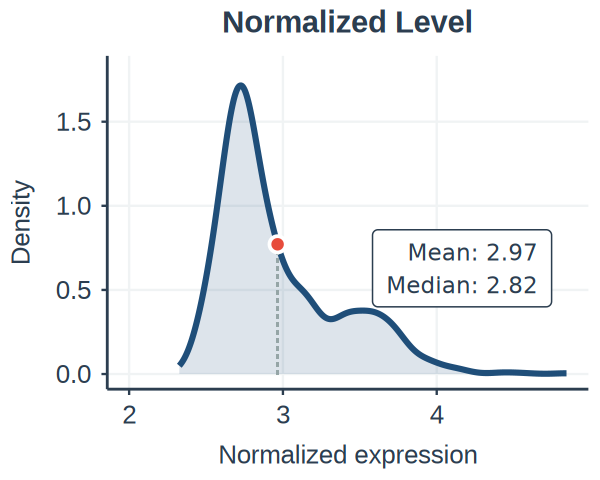

In [9]:
# Fig 2F
options(repr.plot.width = 5, repr.plot.height = 4) 

# Calculate mean expression for each marker 
marker_exp_mean <- apply(marker_exp,2,function(x) mean(x[x>0]))
df_c <- data.frame(value = marker_exp_mean)

# Compute kernel density estimate and summary statistics
dens <- density(df_c$value, na.rm = TRUE)
mean_val <- mean(df_c$value, na.rm = TRUE)
median_val <- median(df_c$value, na.rm = TRUE)
max_y <- max(dens$y)

# Get density height at the mean position for vertical annotation
y_at_mean <- approx(dens$x, dens$y, xout = mean_val)$y


p_c <- ggplot(df_c, aes(x = value)) +
  
  geom_density(fill = "#1F4E79", color = "#1F4E79", linewidth = 1.3, alpha = 0.15) +

  
  geom_segment(
    aes(x = mean_val, y = 0, xend = mean_val, yend = y_at_mean),
    color = "#95A5A6",
    linewidth = 0.6,
    linetype = "dashed"
  ) +

  
  geom_point(
    data = data.frame(x = mean_val, y = y_at_mean),
    aes(x = x, y = y),
    inherit.aes = FALSE,
    shape = 21,
    fill = "#E74C3C",   
    color = "#FFFFFF",  
    stroke = 1.2,       
    size = 3.5          
  ) +

  
  annotate("label",
           x = max(df_c$value, na.rm = TRUE) * 0.98, y = max_y * 0.50,  
           label = paste0(
             "Mean: ", sprintf("%.2f", mean_val), "\n",
             "Median: ", sprintf("%.2f", median_val)
           ),
           hjust = 1, vjust = 1,       
           size = 4.8,                 
           family = "sans",
           color = "#2C3E50",          
           fill = "#FFFFFF",           
           label.size = 0.25,          
           label.r = unit(0.2, "lines"), 
           label.padding = unit(0.5, "lines")
  ) +

  
  labs(title = "Normalized Level",
       x = "Normalized expression",
       y = "Density") +

  
  coord_cartesian(xlim = c(2, max(df_c$value, na.rm = TRUE)), ylim = c(0, max_y * 1.05)) +
  
  
  theme_minimal(base_size = 14) +
  theme(
    
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18, color = "#2C3E50", margin = margin(b = 10)),
    
    axis.title.x = element_text(size = 15, color = "#2C3E50", margin = margin(t = 10)),
    axis.title.y = element_text(size = 15, color = "#2C3E50", margin = margin(r = 10)),
    
    axis.text = element_text(size = 15, color = "#2C3E50"),
    
    axis.line = element_line(color = "#2C3E50", linewidth = 0.6),
    axis.ticks = element_line(color = "#2C3E50", linewidth = 0.5),
    
    panel.grid.major = element_line(color = "#F0F3F4", linewidth = 0.5),
    panel.grid.minor = element_blank()
  )

p_c

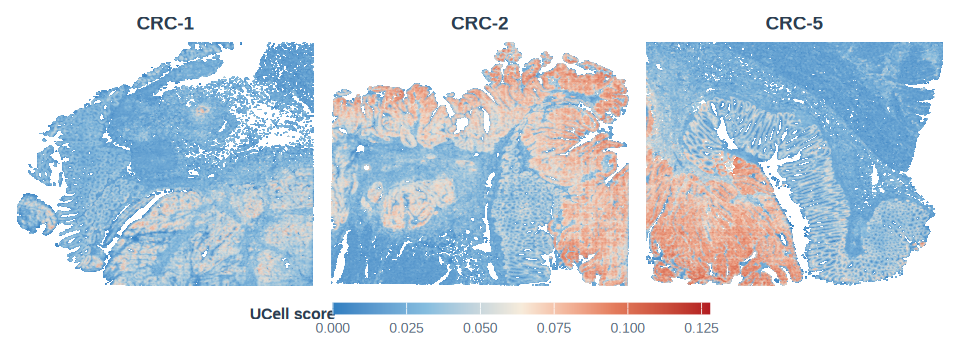

In [10]:
# Fig 2G
options(repr.plot.width = 8, repr.plot.height = 3) 
my_palette <- c(
  "#2F7FC1", 
  "#87BEDF", 
  "#F7ECDB", 
  "#E37B5C", 
  "#B31B21"  
)

theme_spatial_publication <- function() {
  theme_minimal(base_size = 10) +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none", 
    
    
    plot.title = element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50"),
    
  
    plot.margin = margin(t = 5, r = 5, b = -8, l = 5, unit = "pt")
  )
}


p1 <- all_obj[[]] %>% 
  filter(slice == 'CRC1' & tissue == 1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color = marker_sig_UCell)) +
  geom_scattermore(pointsize = 8, pixels = rep(2000, 2)) +
  coord_cartesian(expand = FALSE) +
  scale_color_gradientn(colors=my_palette)+
  ggtitle("CRC-1") +
  theme_spatial_publication()

p2 <- all_obj[[]] %>% 
  filter(slice == 'CRC2' & tissue == 1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color = marker_sig_UCell)) +
  geom_scattermore(pointsize = 8, pixels = rep(2000, 2)) +
  coord_cartesian(expand = FALSE) +
  scale_color_gradientn(colors=my_palette)+
  ggtitle("CRC-2") +
  theme_spatial_publication()

p3 <- all_obj[[]] %>% 
  filter(slice == 'CRC5' & tissue == 1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color = marker_sig_UCell)) +
  geom_scattermore(pointsize = 8, pixels = rep(2000, 2)) +
  coord_cartesian(expand = FALSE) +
  scale_color_gradientn(colors=my_palette)+
  ggtitle("CRC-5") +
  theme_spatial_publication()


p_legend <- all_obj[[]] %>% filter(slice=='CRC1' & tissue==1 & DeconvolutionClass == "singlet") %>%
  ggplot(aes(x = X, y = Y, color=marker_sig_UCell)) +
  geom_scattermore(pointsize = 2, pixels = rep(2000,2))+
  scale_color_gradientn(colors=my_palette)+
  guides(color = guide_colorbar(direction = "horizontal",ticks = FALSE,title='UCell score')) +  # 两行
  theme(legend.position = "top",legend.key.spacing.y = unit(-2, "pt"),plot.margin = margin(0, 0, 0, 0),legend.key.width = unit(1.6, "cm"),      # 拓宽色条，使其舒展大气
    legend.key.height = unit(0.25, "cm"),legend.title = element_text(
      size = 9, 
      face = "bold",                  
      color = "#2C3E50", 
      margin = margin(b = 6)                 
    ), 
    legend.text = element_text(
      size = 8, 
      color = "#5D6D7E"                      
    ))    

legend <- get_legend(p_legend)


((p1 | p2 | p3) / legend) + 
  plot_layout(heights = c(1,0.2))


Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `size` argu

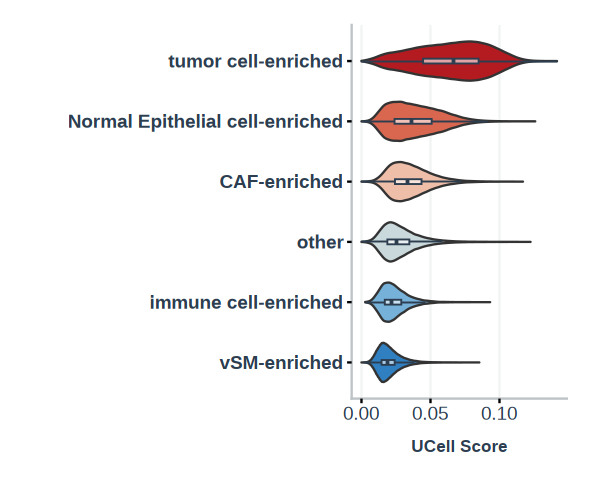

In [11]:
# Fig 2H
options(repr.plot.width = 5, repr.plot.height = 4) 

new_title <- "Signature Score Distribution" 
my_palette <- c("#2F7FC1", "#87BEDF", "#F7ECDB", "#E37B5C", "#B31B21") 



df <- FetchData(all_obj, vars = c("marker_sig_UCell", "region"))
stats_df <- df %>%
  group_by(region) %>%
  summarise(median_val = median(marker_sig_UCell)) %>%
  arrange(median_val)

order_cluster <- stats_df$region


col_fun <- colorRampPalette(my_palette)

cluster_colors <- col_fun(length(order_cluster))
names(cluster_colors) <- order_cluster


all_obj$region <- factor(all_obj$region, levels = order_cluster)
Idents(all_obj) <- "region"



p_vln <- VlnPlot(
  all_obj,
  features = "marker_sig_UCell", 
  pt.size = 0,               
  cols = cluster_colors      
) 
for (i in seq_along(p_vln$layers)) {
  if (inherits(p_vln$layers[[i]]$geom, "GeomViolin")) {
    p_vln$layers[[i]]$geom_params$width <- 0.65 
  }
}
p_vln <- p_vln+ 
  
  geom_boxplot(
    width = 0.08, 
    fill = "white", 
    color = "#2C3E50", 
    outlier.shape = NA, 
    alpha = 0.6,
    size = 0.4
  ) +
  
  coord_flip() + 
  
  NoLegend() +  
  
  theme_classic() +
  theme(
    
    plot.title = element_text(size = 13, face = "bold", color = "#2C3E50", hjust = 0.5, margin = margin(b = 15)),
    
    
    axis.text.y = element_text(size = 11, face = "bold", color = "#2C3E50"),
    axis.text.x = element_text(size = 11, color = "#2C3E50"),
    
    
    axis.title.y = element_blank(), 
    axis.title.x = element_text(size = 10, face = "bold", color = "#2C3E50", margin = margin(t = 10)),
    
    
    panel.grid.major.x = element_line(color = "#F2F4F4", size = 0.5), 
    
    
    axis.line = element_line(color = "#BDC3C7", size = 0.5),
    plot.margin = margin(t = 10, r = 15, b = 10, l = 10, unit = "pt"),legend.position = "none"
  ) +
  
  labs(
    title = NULL,
    y = "UCell Score" 
  )


p_vln

In [12]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 16.04.6 LTS

Matrix products: default
BLAS/LAPACK: /home/amax/anaconda3/envs/cty3/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8           LC_NUMERIC=C              
 [3] LC_TIME=zh_CN.UTF-8        LC_COLLATE=C              
 [5] LC_MONETARY=zh_CN.UTF-8    LC_MESSAGES=C             
 [7] LC_PAPER=zh_CN.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=zh_CN.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] circlize_0.4.17       ComplexHeatmap_2.22.0 cowplot_1.2.0        
 [4] distances_0.1.13      pheatmap_1.0.13       arrow_21.0.0         
 [7] paletteer_1.6.0       furrr_0.3.1           future_1.67.0        
[10] RColor